## 1. Locate the project and model

Copy your trained `model.pt` into the project, then set `MODEL_PATH` to its exact local path. The notebook creates an `uploads/` folder in the project for test photos.

In [1]:
import sys
from pathlib import Path

def find_project_dir(start_dir: Path) -> Path:
    for candidate in (start_dir, *start_dir.parents):
        if (candidate / 'src' / 'model.py').is_file():
            return candidate
    raise RuntimeError(
        'Could not find the face-recognition project above '
        f'the current directory: {start_dir}'
    )

PROJECT_DIR = find_project_dir(Path.cwd().resolve())

sys.path.insert(0, str(PROJECT_DIR / 'src'))
MODEL_PATH = PROJECT_DIR / 'checkpoints' / 'model.pt'
UPLOADS_DIR = PROJECT_DIR / 'uploads'
UPLOADS_DIR.mkdir(exist_ok=True)

if not MODEL_PATH.is_file():
    raise FileNotFoundError(f'Model checkpoint was not found: {MODEL_PATH}')

print('Project directory:', PROJECT_DIR)
print('Model checkpoint:', MODEL_PATH)
print('Uploads directory:', UPLOADS_DIR)

Project directory: B:\My Personal Projects\face-recognition
Model checkpoint: B:\My Personal Projects\face-recognition\checkpoints\model.pt
Uploads directory: B:\My Personal Projects\face-recognition\uploads


## 2. Load the trained model

The notebook loads only the saved weights. `model.eval()` makes BatchNorm use its learned statistics and disables training behaviour.

In [2]:
import torch

from model import FaceEmbedder, validate_checkpoint_metadata

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
fine_tuning, initialization = validate_checkpoint_metadata(checkpoint)

model = FaceEmbedder(initialization='scratch').to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Device:', device)
print('Checkpoint fine-tuning mode:', fine_tuning)
print('Checkpoint initialization:', initialization)

Device: cuda
Checkpoint fine-tuning mode: all
Checkpoint initialization: imagenet


## 3. Add local test photos

Manually copy three JPEG or PNG files into the printed `uploads/` folder. Use two photos of the same person and one photo of another person. Each image must contain exactly one clear face.

In [3]:
IMAGE_FILENAMES = {
    'same_person_photo_1': 'same_1.jpeg',
    'same_person_photo_2': 'same_2.jpeg',
    'different_person_photo': 'different.jpeg',
}

image_paths = {name: UPLOADS_DIR / filename for name, filename in IMAGE_FILENAMES.items()}
missing_files = [path for path in image_paths.values() if not path.is_file()]
if missing_files:
    expected = '\n'.join(f'- {path.name}' for path in missing_files)
    raise FileNotFoundError(
        f'Copy these files into {UPLOADS_DIR}:\n{expected}'
    )

print('Using local images:')
for path in image_paths.values():
    print('-', path)

Using local images:
- B:\My Personal Projects\face-recognition\uploads\same_1.jpeg
- B:\My Personal Projects\face-recognition\uploads\same_2.jpeg
- B:\My Personal Projects\face-recognition\uploads\different.jpeg


## 4. Detect, align, and embed faces

YuNet reads each local image, detects exactly one face, and aligns it. The model converts the aligned face into a normalised 512-number embedding.

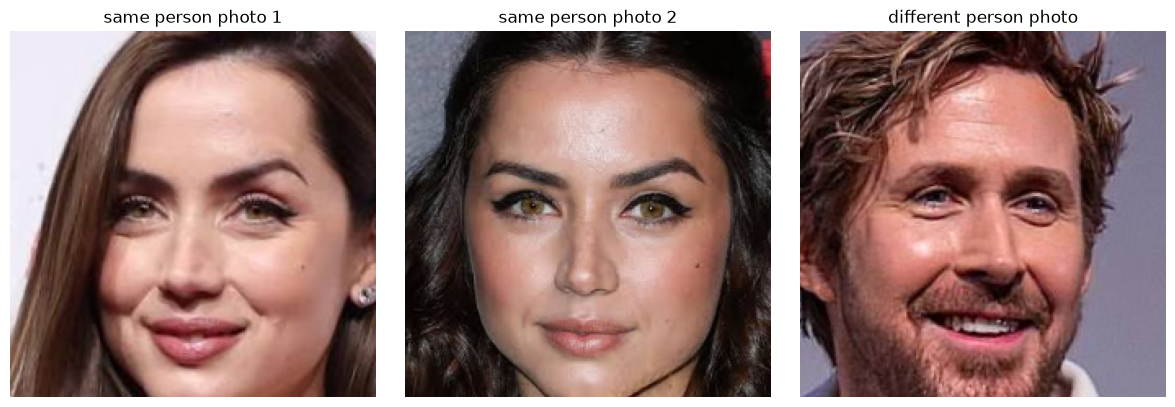

Embedding shape: (512,)


In [4]:
import matplotlib.pyplot as plt
import numpy as np

from config import IMAGENET_MEAN, IMAGENET_STD
from vision import FacePreprocessor, VisionError

def face_to_tensor(face: np.ndarray) -> torch.Tensor:
    image = torch.from_numpy(face).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image - mean) / std

def create_embedding(face: np.ndarray) -> torch.Tensor:
    image = face_to_tensor(face).unsqueeze(0).to(device)
    with torch.inference_mode():
        return model(image).squeeze(0).cpu()

preprocessor = FacePreprocessor()
aligned_faces = {}
embeddings = {}

for name, path in image_paths.items():
    try:
        face = preprocessor.preprocess(path.read_bytes())
    except VisionError as error:
        raise RuntimeError(f'{name}: {error.code} — {error}') from error
    aligned_faces[name] = face
    embeddings[name] = create_embedding(face)

figure, axes = plt.subplots(1, len(aligned_faces), figsize=(12, 4))
for axis, (name, face) in zip(np.atleast_1d(axes), aligned_faces.items()):
    axis.imshow(face)
    axis.set_title(name.replace('_', ' '))
    axis.axis('off')
plt.tight_layout()
plt.show()

print('Embedding shape:', tuple(embeddings['same_person_photo_1'].shape))

## 5. Compare the faces

`THRESHOLD=0.2086` is the validation threshold from the ImageNet full-fine-tuning experiment. Use it only with that matching checkpoint. A higher score means the model considers two faces more similar.

In [5]:
import pandas as pd

THRESHOLD = 0.2086

pairs = [
    ('Same person', 'same_person_photo_1', 'same_person_photo_2'),
    ('Different people', 'same_person_photo_1', 'different_person_photo'),
]

rows = []
for expected, first_name, second_name in pairs:
    similarity = float(torch.dot(embeddings[first_name], embeddings[second_name]))
    rows.append({
        'expected_pair': expected,
        'similarity': similarity,
        'threshold': THRESHOLD,
        'model_decision': 'same person' if similarity >= THRESHOLD else 'different people',
    })

comparison_table = pd.DataFrame(rows)
display(comparison_table.round(4))

for row in rows:
    print(
        f"{row['expected_pair']}: similarity={row['similarity']:.4f} → "
        f"{row['model_decision']}"
    )

,expected_pair,similarity,threshold,model_decision
0,Same person,0.5825,0.2086,same person
1,Different people,0.2883,0.2086,same person


Same person: similarity=0.5825 → same person
Different people: similarity=0.2883 → same person


## 6. Run InsightFace `buffalo_l` recognition ONNX model — ONNX-RUNTIME VERSION

This uses the official pretrained `w600k_r50.onnx` recognition model from the `buffalo_l` release. It does not import the `insightface` Python package. On the first run it downloads the ONNX model once into `models/buffalo_l/`.

In [6]:
from shutil import copyfileobj
from urllib.request import urlretrieve
from zipfile import ZipFile

import cv2
import onnxruntime as ort

BUFFALO_L_ARCHIVE_URL = (
    'https://github.com/deepinsight/insightface/releases/download/v0.7/buffalo_l.zip'
)
BUFFALO_L_DIR = PROJECT_DIR / 'models' / 'buffalo_l'
BUFFALO_L_DIR.mkdir(parents=True, exist_ok=True)
BUFFALO_L_RECOGNITION_PATH = BUFFALO_L_DIR / 'w600k_r50.onnx'

if not BUFFALO_L_RECOGNITION_PATH.is_file():
    archive_path = BUFFALO_L_DIR / 'buffalo_l.zip'
    print('Downloading official buffalo_l weights. This happens once.')
    urlretrieve(BUFFALO_L_ARCHIVE_URL, archive_path)
    with ZipFile(archive_path) as archive:
        recognition_member = next(
            name for name in archive.namelist() if name.endswith('w600k_r50.onnx')
        )
        with archive.open(recognition_member) as source, BUFFALO_L_RECOGNITION_PATH.open('wb') as destination:
            copyfileobj(source, destination)

recognition_session = ort.InferenceSession(
    str(BUFFALO_L_RECOGNITION_PATH),
    providers=['CPUExecutionProvider'],
)
recognition_input_name = recognition_session.get_inputs()[0].name

def create_buffalo_l_embedding(face: np.ndarray) -> np.ndarray:
    face_112 = cv2.resize(face, (112, 112), interpolation=cv2.INTER_AREA)
    input_tensor = (face_112.astype(np.float32) - 127.5) / 128.0
    input_tensor = np.ascontiguousarray(input_tensor.transpose(2, 0, 1)[None])
    embedding = recognition_session.run(
        None, {recognition_input_name: input_tensor}
    )[0][0]
    return embedding / np.linalg.norm(embedding)

buffalo_l_embeddings = {
    name: create_buffalo_l_embedding(face)
    for name, face in aligned_faces.items()
}
print('buffalo_l embedding shape:', buffalo_l_embeddings['same_person_photo_1'].shape)

buffalo_l embedding shape: (512,)


## 7. Compare the current model and `buffalo_l`

The similarity values and thresholds of different models are not directly interchangeable. Compare whether each model gives a higher similarity for the same-person pair than for the different-person pair, and compare the separation margin.

In [8]:
def compare_embedding_pairs(
    model_name: str,
    embedding_values: dict[str, np.ndarray],
) -> list[dict[str, object]]:
    pair_definitions = [
        ('Same person', 'same_person_photo_1', 'same_person_photo_2'),
        ('Different people', 'same_person_photo_1', 'different_person_photo'),
    ]
    return [
        {
            'model': model_name,
            'expected_pair': expected_pair,
            'cosine_similarity': float(
                np.dot(embedding_values[first_name], embedding_values[second_name])
            ),
        }
        for expected_pair, first_name, second_name in pair_definitions
    ]

resnet_embeddings = {name: embedding.numpy() for name, embedding in embeddings.items()}
all_comparisons = compare_embedding_pairs('Current ResNet18', resnet_embeddings)
all_comparisons += compare_embedding_pairs('InsightFace buffalo_l', buffalo_l_embeddings)
comparison_by_model = pd.DataFrame(all_comparisons)
display(comparison_by_model.round(4))

summary_rows = []
for model_name, group in comparison_by_model.groupby('model', sort=False):
    same_similarity = float(
        group.loc[group['expected_pair'] == 'Same person', 'cosine_similarity'].iloc[0]
    )
    different_similarity = float(
        group.loc[group['expected_pair'] == 'Different people', 'cosine_similarity'].iloc[0]
    )
    summary_rows.append({
        'model': model_name,
        'same_person_similarity': same_similarity,
        'different_person_similarity': different_similarity,
        'separation_margin': same_similarity - different_similarity,
    })

model_comparison_summary = pd.DataFrame(summary_rows)
display(model_comparison_summary.round(4))

,model,expected_pair,cosine_similarity
0,Current ResNet18,Same person,0.5825
1,Current ResNet18,Different people,0.2883
2,InsightFace buffalo_l,Same person,0.7405
3,InsightFace buffalo_l,Different people,0.0669


,model,same_person_similarity,different_person_similarity,separation_margin
0,Current ResNet18,0.5825,0.2883,0.2942
1,InsightFace buffalo_l,0.7405,0.0669,0.6736


## 8. Interpret the result

A successful small check has a same-person similarity above the threshold and a different-person similarity below it. One pair is only a manual smoke test, not a measurement of model accuracy. Use varied photos: different pose, lighting, background, and expression.